In [35]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import os
import shutil
import rasterio
from rasterio.windows import Window
from pyproj import Transformer
from sklearn.model_selection import train_test_split

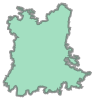

In [8]:
del_ncrdf=gpd.read_file("~/delairshed/delhi_ncr_region.geojson")
del_ncrdf['geometry'][0]

In [3]:
del_ncrdf['geometry']

0     POLYGON ((76.85108 28.22115, 76.85219 28.22098...
1     POLYGON ((77.15903 29.29436, 77.15999 29.29427...
2     MULTIPOLYGON (((77.07565 27.27704, 77.07819 27...
3     POLYGON ((77.97073 28.71104, 77.97089 28.71096...
4     POLYGON ((77.2143 28.78524, 77.21521 28.78514,...
5     POLYGON ((77.39054 28.63475, 77.39107 28.63431...
6     POLYGON ((77.45693 28.92601, 77.4587 28.92535,...
7     POLYGON ((78.05232 28.88322, 78.05345 28.88317...
8     POLYGON ((77.59747 29.25693, 77.59772 29.25677...
9     POLYGON ((77.94034 29.71194, 77.94094 29.71084...
10    POLYGON ((77.20369 28.64315, 77.20406 28.64298...
11    POLYGON ((77.23588 28.77073, 77.23606 28.76963...
12    POLYGON ((76.96044 28.81534, 76.96176 28.81481...
13    POLYGON ((77.32015 28.713, 77.32036 28.71291, ...
14    POLYGON ((77.22142 29.69728, 77.2243 29.6953, ...
15    POLYGON ((77.25738 28.60641, 77.2579 28.60535,...
16    POLYGON ((76.01183 29.06029, 76.01279 29.06018...
17    MULTIPOLYGON (((77.16826 28.2933, 77.16954

<Axes: >

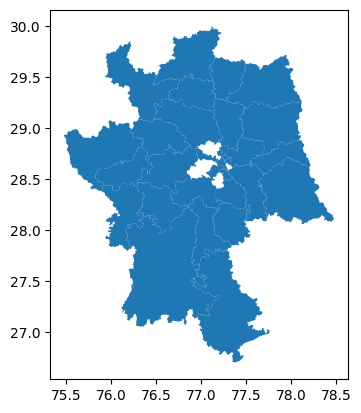

In [6]:
del_ncrdf.plot()

In [16]:
del_airshedf=gpd.read_file("~/delairshed/delhi_airshed.geojson")
del_airshedf['geometry']

0    POLYGON ((76.85 28.27, 76.85 28.28, 76.85 28.2...
Name: geometry, dtype: geometry

In [27]:
print(del_ncrdf.crs, del_airshedf.crs)

EPSG:4326 EPSG:4326


In [28]:
print(del_ncrdf.geometry.name, del_airshedf.geometry.name)

geometry geometry


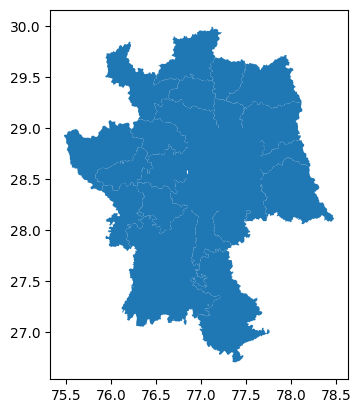

In [32]:
merged=pd.concat([del_ncrdf, del_airshedf], ignore_index=True)
merged.plot()
plt.show()

## The region in the centre was having patches hence I merged the Delhi airshed patch over here, I'll testing the merged and the one which is not merged, i suppose the unmerged one would filter more regions off.

In [35]:
merged.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## EPSG: 4326 cannot be used as it indicates latitudes and longitudes, hence EPSG: 3857 is to be used as it deals in meters.

In [38]:
mergedmet=merged.to_crs(epsg=3857)
cellsz=60000
mergedmet.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
gridcells=[]
mmin, nmin, mmax, nmax=mergedmet.total_bounds
for m in np.arange(mmin,mmax,cellsz):
    for n in np.arange(nmin,nmax,cellsz):
        gridcells.append(box(m,n,m+cellsz,n+cellsz))
grid=gpd.GeoDataFrame(geometry=gridcells,crs=mergedmet.crs)

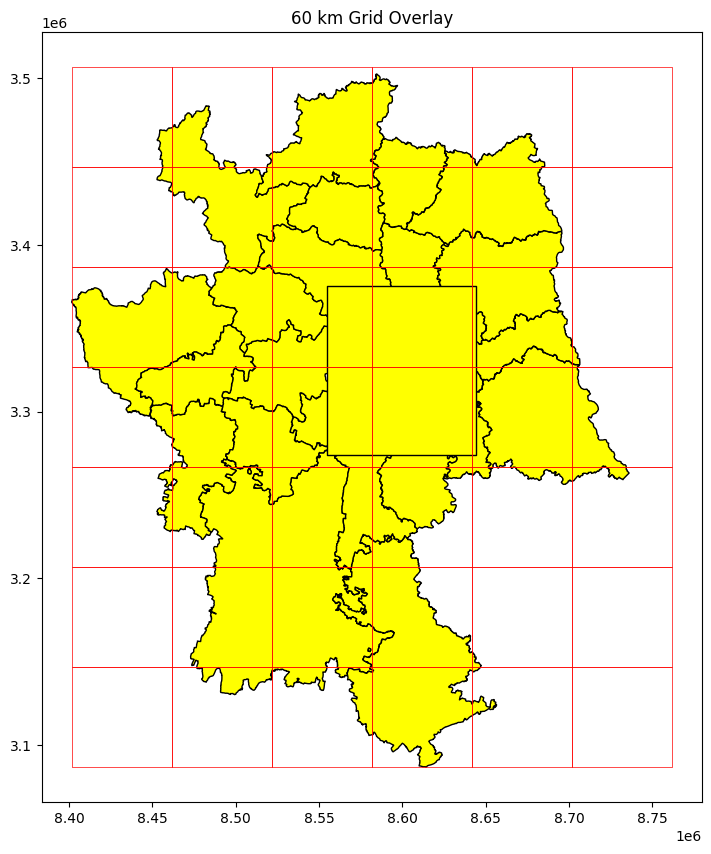

In [44]:
fig,ax=plt.subplots(figsize=(10,10))
mergedmet.plot(ax=ax,color="yellow", edgecolor="black")
grid.boundary.plot(ax=ax,color='red',linewidth=0.5)
plt.title("60 km Grid Overlay with merged")
plt.show()

## Above is directly from the merged shapefile of the delhi-ncr as well as delhi arished which covers up the centre patch

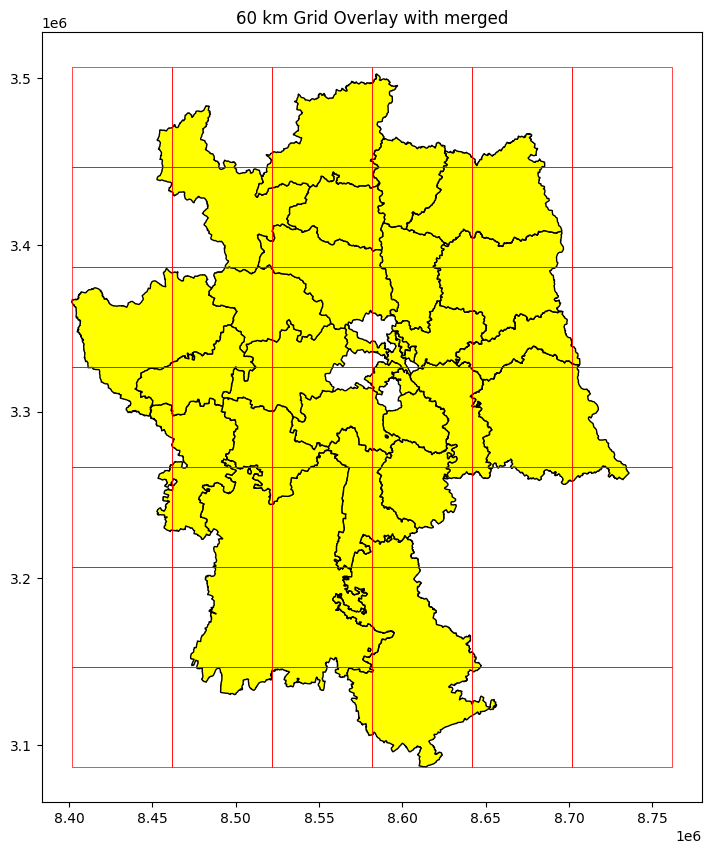

In [54]:
del_ncrmet=del_ncrdf.to_crs(epsg=3857)

gridcells=[]
mmin, nmin, mmax, nmax=del_ncrmet.total_bounds
for m in np.arange(mmin,mmax,cellsz):
    for n in np.arange(nmin,nmax,cellsz):
        gridcells.append(box(m,n,m+cellsz,n+cellsz))
grid=gpd.GeoDataFrame(geometry=gridcells,crs=mergedmet.crs)

fig,ax=plt.subplots(figsize=(10,10))
del_ncrmet.plot(ax=ax,color="yellow", edgecolor="black")
grid.boundary.plot(ax=ax,color='red',linewidth=0.5)
plt.title("60 km Grid Overlay with merged")
plt.show()

## Above is directly from the delhi-ncr shapefile which has the patches in the center

<Axes: >

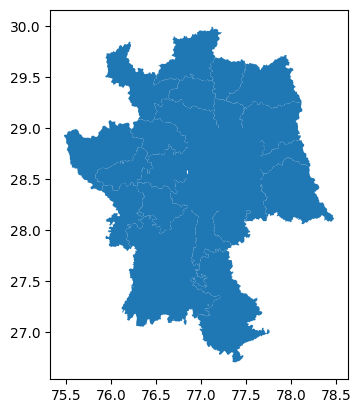

In [65]:
merged.plot()

<Axes: >

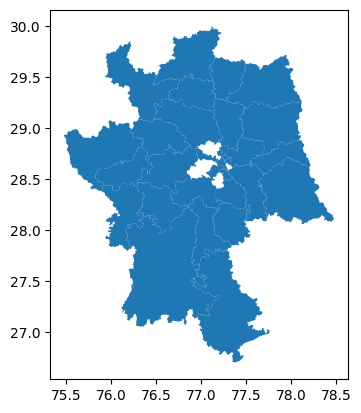

In [67]:
del_ncrdf.plot()

In [59]:
dirpth="/home/aderham/delairshed/rgb/"
count=sum(1 for img in os.listdir(dirpth) if img.endswith(".png"))
print("number of images before filtering: ",count)

number of images before filtering:  9216


In [10]:
folder="/home/aderham/delairshed/rgb/"
data=[]
for sentim in os.listdir(folder):
    if sentim.endswith(".png"):
        lat,lon=sentim.replace(".png","").split("_")
        data.append({
            "filename": sentim,
            "lat":float(lat),
            "lon":float(lon)
        })
df=pd.DataFrame(data)

In [71]:
df

,filename,lat,lon
0,28.2090_76.9409.png,28.2090,76.9409
1,28.6557_77.4443.png,28.6557,77.4443
2,28.3943_76.9558.png,28.3943,76.9558
3,28.4556_77.1645.png,28.4556,77.1645
4,28.7056_77.4233.png,28.7056,77.4233
...,...,...,...
9211,28.3442_77.5410.png,28.3442,77.5410
9212,28.6091_77.1146.png,28.6091,77.1146
9213,28.8767_77.4910.png,28.8767,77.4910
9214,28.7442_77.5146.png,28.7442,77.5146


In [11]:
gdfpts=gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

In [12]:
filtered= gpd.sjoin(gdfpts,del_ncrdf,predicate="within")

In [79]:
merged=merged.dissolve()
filteredmerge=gpd.sjoin(gdfpts,merged,predicate="within")

In [76]:
validims=filtered["filename"].tolist()
print("Numeber of images after filtering for delhi_ncr: ",len(validims))

Numeber of images after filtering for delhi_ncr:  8015


In [80]:
validimsmerge=filteredmerge["filename"].tolist()
print("Numeber of images after filtering for delhi_ncr merged with the airshed shapefile: ",len(validimsmerge))

Numeber of images after filtering for delhi_ncr merged with the airshed shapefile:  9216


### An interesting observation is that the merged shapefile shows doesn't come to any benifit with respect to the problem statement as the image set isn't being filtered. This gives an insight that the airshed shapefile wasn't to be combined with the delhi_ncr shapefile to begin with. For the further course of the implementation, delhi_ncr shapefile derived geodataframe's filtered images will be used.

In [ ]:
print(validims)

In [85]:
src="/home/aderham/delairshed/rgb/"
dst="/home/aderham/delairshed/filtered_rgb/"
os.makedirs(dst,exist_ok=True)

for f in validims:
    shutil.copy(os.path.join(src, f), os.path.join(dst,f))

In [2]:
src=rasterio.open("/home/aderham/delairshed/worldcover_bbox_delhi_ncr_2021.tif")
src.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [7]:
transformer=Transformer.from_crs("EPSG:4326",src.crs,always_xy=True)

In [13]:
patchsz=128
half=patchsz//2
patches=[]

for _, row in filtered.iterrows():
    lon,lat=row["lon"],row["lat"]

    x,y=transformer.transform(lon,lat)
    rowpx,colpx=src.index(x,y)

    win=Window(colpx - half, rowpx - half, patchsz, patchsz)
    patch=src.read(1,window=win)

    patches.append(patch)
    

In [14]:
print(patches)

[array([[40, 40, 40, ..., 50, 50, 50],
       [40, 40, 40, ..., 50, 50, 50],
       [40, 40, 40, ..., 50, 50, 50],
       ...,
       [40, 40, 40, ..., 50, 40, 40],
       [40, 40, 40, ..., 40, 40, 40],
       [40, 40, 40, ..., 40, 40, 40]], shape=(128, 128), dtype=uint8), array([[50, 50, 50, ..., 50, 50, 50],
       [10, 10, 50, ..., 50, 50, 50],
       [10, 10, 10, ..., 50, 50, 50],
       ...,
       [50, 50, 50, ..., 10, 10, 10],
       [50, 50, 50, ..., 40, 10, 10],
       [50, 50, 50, ..., 40, 10, 10]], shape=(128, 128), dtype=uint8), array([[30, 30, 30, ..., 30, 60, 50],
       [30, 30, 30, ..., 50, 60, 60],
       [30, 30, 30, ..., 50, 60, 50],
       ...,
       [50, 50, 50, ..., 30, 50, 50],
       [50, 50, 50, ..., 30, 30, 50],
       [50, 50, 50, ..., 30, 30, 30]], shape=(128, 128), dtype=uint8), array([[30, 30, 30, ..., 40, 40, 40],
       [30, 30, 30, ..., 40, 40, 40],
       [30, 30, 30, ..., 40, 40, 40],
       ...,
       [50, 50, 50, ..., 50, 50, 50],
       [50, 50, 

In [15]:
labels = []
for patch in patches:
    values,counts=np.unique(patch,return_counts=True)
    domclass=values[np.argmax(counts)]
    labels.append(domclass)

In [18]:
esa_to_label = {
    10: "Tree_cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare_sparse_veg",
    70: "Snow_ice",
    80: "Water",
    90: "Herbaceous_wetland",
    95: "Mangroves",
    100: "Other",
}

In [21]:
type(filtered)

geopandas.geodataframe.GeoDataFrame

In [51]:
filtered = filtered.reset_index(drop=True)
filtered["esa_label"] = labels

,filename,lat,lon,geometry,index_right,esa_label,final_label,lclabel
0,28.2090_76.9409.png,28.2090,76.9409,POINT (76.9409 28.209),23,40,Cropland,Cropland
1,28.6557_77.4443.png,28.6557,77.4443,POINT (77.4443 28.6557),6,50,Built-up,Built-up
2,28.3943_76.9558.png,28.3943,76.9558,POINT (76.9558 28.3943),18,50,Built-up,Built-up
3,28.7056_77.4233.png,28.7056,77.4233,POINT (77.4233 28.7056),6,50,Built-up,Built-up
4,28.6557_77.1909.png,28.6557,77.1909,POINT (77.1909 28.6557),4,50,Built-up,Built-up
...,...,...,...,...,...,...,...,...
8010,28.3442_77.5410.png,28.3442,77.5410,POINT (77.541 28.3442),5,30,Grassland,Grassland
8011,28.6091_77.1146.png,28.6091,77.1146,POINT (77.1146 28.6091),10,50,Built-up,Built-up
8012,28.8767_77.4910.png,28.8767,77.4910,POINT (77.491 28.8767),6,40,Cropland,Cropland
8013,28.7442_77.5146.png,28.7442,77.5146,POINT (77.5146 28.7442),6,40,Cropland,Cropland


In [55]:
filtered["lclabel"] = filtered["esa_label"].map(esa_to_label)
filtered["lclabel"] = filtered["lclabel"].fillna("Others")

In [56]:
filtered

,filename,lat,lon,geometry,index_right,esa_label,lclabel
0,28.2090_76.9409.png,28.2090,76.9409,POINT (76.9409 28.209),23,40,Cropland
1,28.6557_77.4443.png,28.6557,77.4443,POINT (77.4443 28.6557),6,50,Built-up
2,28.3943_76.9558.png,28.3943,76.9558,POINT (76.9558 28.3943),18,50,Built-up
3,28.7056_77.4233.png,28.7056,77.4233,POINT (77.4233 28.7056),6,50,Built-up
4,28.6557_77.1909.png,28.6557,77.1909,POINT (77.1909 28.6557),4,50,Built-up
...,...,...,...,...,...,...,...
8010,28.3442_77.5410.png,28.3442,77.5410,POINT (77.541 28.3442),5,30,Grassland
8011,28.6091_77.1146.png,28.6091,77.1146,POINT (77.1146 28.6091),10,50,Built-up
8012,28.8767_77.4910.png,28.8767,77.4910,POINT (77.491 28.8767),6,40,Cropland
8013,28.7442_77.5146.png,28.7442,77.5146,POINT (77.5146 28.7442),6,40,Cropland


In [57]:
print(filtered["lclabel"].isna().sum())

0


### No sign of null values :))

In [60]:
filtered[["filename", "lclabel"]].to_csv("/home/aderham/delairshed/landcoverlabels.csv", index=False)

In [65]:
train,test=train_test_split(filtered, test_size=0.4, random_state=42)
print("Train:\n",train_df["lclabel"].value_counts())
print("\nTest:\n",test_df["lclabel"].value_counts())

Train:
 lclabel
Cropland              3257
Built-up              1097
Tree_cover             205
Shrubland              136
Grassland              109
Water                    3
Herbaceous_wetland       2
Name: count, dtype: int64

Test:
 lclabel
Cropland      2217
Built-up       682
Tree_cover     136
Shrubland      110
Grassland       57
Water            4
Name: count, dtype: int64


<Axes: title={'center': 'Overall'}, xlabel='lclabel'>

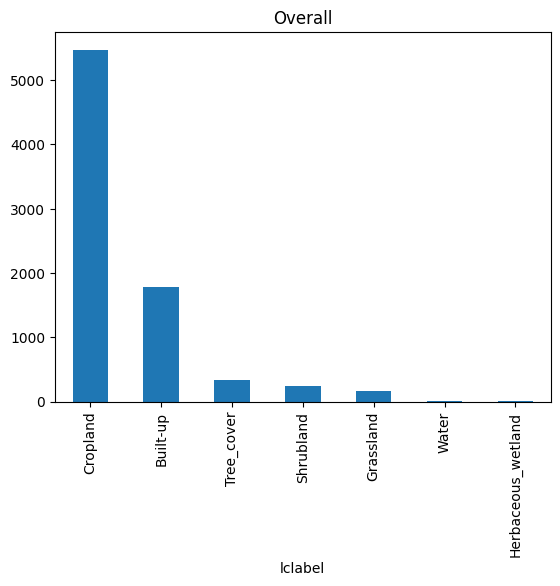

In [62]:
filtered["lclabel"].value_counts().plot(kind="bar", title="Overall")

<Axes: title={'center': 'Train'}, xlabel='lclabel'>

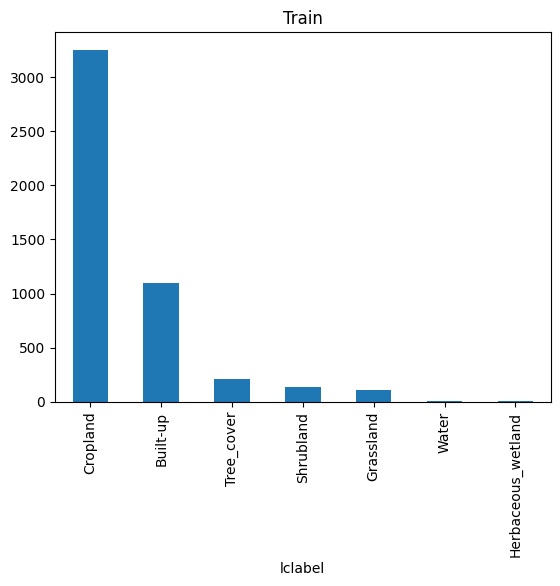

In [66]:
train["lclabel"].value_counts().plot(kind="bar", title="Train")

<Axes: title={'center': 'Train'}, xlabel='lclabel'>

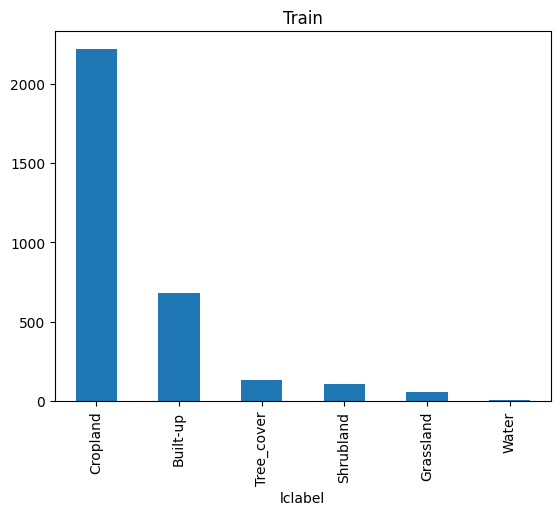

In [67]:
test["lclabel"].value_counts().plot(kind="bar", title="Train")

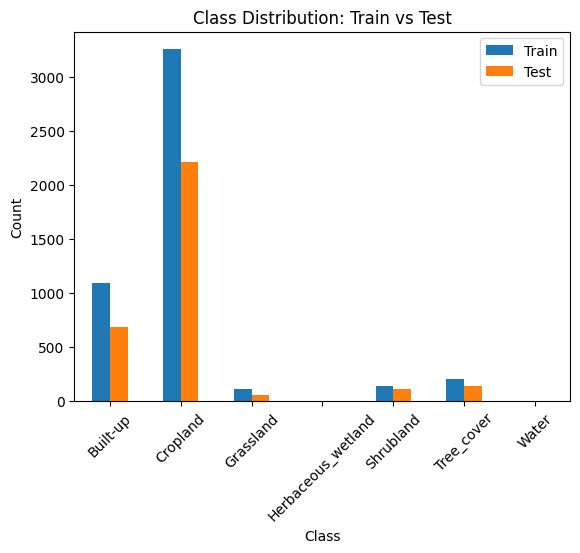

In [70]:
train_counts = train_df["lclabel"].value_counts()
test_counts = test_df["lclabel"].value_counts()

dfplt = pd.DataFrame({"Train": train_counts,"Test": test_counts})
dfplt.plot(kind="bar")

plt.title("Class Distribution: Train vs Test")
plt.ylabel("Count")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.show()